In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("./data/cleaned_house_data.csv")
df.head()

,mssubclass,mszoning,lotfrontage,lotarea,street,lotshape,landcontour,utilities,lotconfig,landslope,...,enclosedporch,3ssnporch,screenporch,poolarea,miscval,mosold,yrsold,saletype,salecondition,saleprice
0,60,rl,65.0,8450,pave,reg,lvl,allpub,inside,gtl,...,0,0,0,0,0,2,2008,wd,normal,208500
1,20,rl,80.0,9600,pave,reg,lvl,allpub,fr2,gtl,...,0,0,0,0,0,5,2007,wd,normal,181500
2,60,rl,68.0,11250,pave,ir1,lvl,allpub,inside,gtl,...,0,0,0,0,0,9,2008,wd,normal,223500
3,70,rl,60.0,9550,pave,ir1,lvl,allpub,corner,gtl,...,272,0,0,0,0,2,2006,wd,abnorml,140000
4,60,rl,84.0,14260,pave,ir1,lvl,allpub,fr2,gtl,...,0,0,0,0,0,12,2008,wd,normal,250000


Since there is no predictive values and variance in the *<span style = "color: violet;">utility column</span>*, dropping it would be the best uption inorder to avoid inbalance data values caused from that column

In [3]:
df = df.drop(columns=["utilities"])

Checking for missing values  
Checking for skewness in the target column (saleprice)  
Checking for duplicates  
Checking for 0 inputation in these columns: *<span style = "color: violet;">"grlivarea","lotarea","garagearea"</span>*  
Checking for ouliers in this columns: *<span style = "color: violet;">"saleprice","grlivarea","lotarea"</span>*  

In [4]:
df.isna().sum().sum()

np.int64(0)

In [5]:
df["saleprice"].skew()

np.float64(1.8828757597682129)

According to the above result, it showed the target column is heavily right-skewed and applying log-transformed to it would shrink it into being assymetric or normal.

This result above is a little more ok compare to the positive skeness before log-transforming the column

In [6]:
# Checking for duplicates
df.duplicated().sum().sum()

np.int64(0)

In [7]:
try:
    (df[["grlivarea","lotarea","garagearea"]==0]).sum()
except Exception as e:
    print(f"There is no 0 imputs: {e}")

There is no 0 imputs: False


In [8]:
df[["saleprice","grlivarea","lotarea"]].describe()

,saleprice,grlivarea,lotarea
count,1460.000000,1460.000000,1460.000000
mean,180921.195890,1515.463699,10516.828082
std,79442.502883,525.480383,9981.264932
min,34900.000000,334.000000,1300.000000
25%,129975.000000,1129.500000,7553.500000
50%,163000.000000,1464.000000,9478.500000
75%,214000.000000,1776.750000,11601.500000
max,755000.000000,5642.000000,215245.000000


In [9]:
data = df[df["saleprice"] < 400000]
data.head()

,mssubclass,mszoning,lotfrontage,lotarea,street,lotshape,landcontour,lotconfig,landslope,neighborhood,...,enclosedporch,3ssnporch,screenporch,poolarea,miscval,mosold,yrsold,saletype,salecondition,saleprice
0,60,rl,65.0,8450,pave,reg,lvl,inside,gtl,collgcr,...,0,0,0,0,0,2,2008,wd,normal,208500
1,20,rl,80.0,9600,pave,reg,lvl,fr2,gtl,veenker,...,0,0,0,0,0,5,2007,wd,normal,181500
2,60,rl,68.0,11250,pave,ir1,lvl,inside,gtl,collgcr,...,0,0,0,0,0,9,2008,wd,normal,223500
3,70,rl,60.0,9550,pave,ir1,lvl,corner,gtl,crawfor,...,272,0,0,0,0,2,2006,wd,abnorml,140000
4,60,rl,84.0,14260,pave,ir1,lvl,fr2,gtl,noridge,...,0,0,0,0,0,12,2008,wd,normal,250000


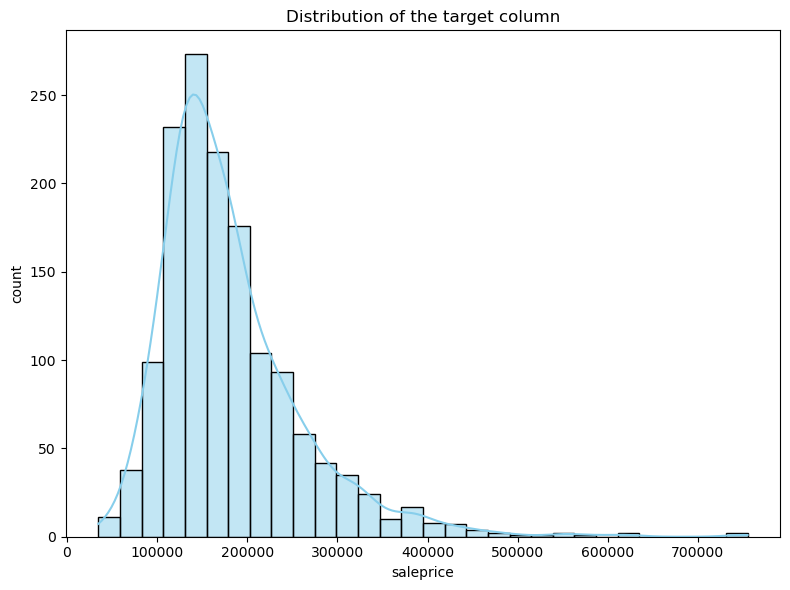

In [10]:
# Visualising the skewness of the target
plt.figure(figsize=(8, 6))
sns.histplot(df["saleprice"], bins=30, kde=True, color="skyblue")
plt.title("Distribution of the target column")
plt.xlabel("saleprice")
plt.ylabel("count")
plt.tight_layout()
plt.show()

This shows that the target column is heavily right-skewed and this might influence the non-tree models especially the linear regression into being bias in it prediction. So the best step i can take is drafting the target column into a column where the maximum value is not more than 400,000 and then drop the ones that are more than that value

Visualizing the outliers through some plots. Discovered the ground living area is one of the major influencer of the outliers and this was discovered from the saleprice gotten from the square feets iquivalent to 4000sqft. The living ground areal shows the total finishes sqarefeet of the basement or building below the real upward building  

Visualising through scatter plot

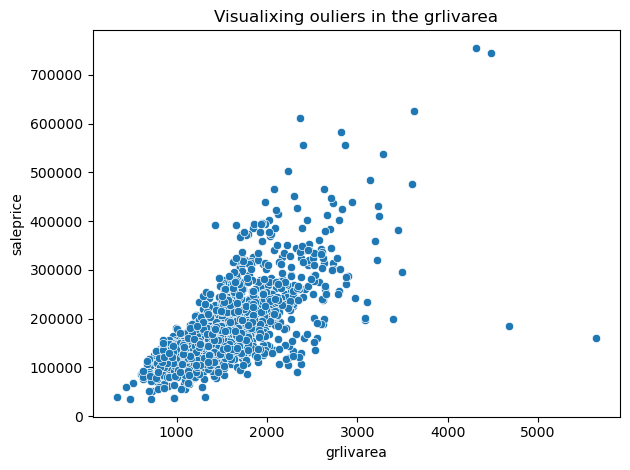

In [11]:
sns.scatterplot(data=df, x="grlivarea", y="saleprice")
plt.title("Visualixing ouliers in the grlivarea")
plt.xlabel("grlivarea")
plt.ylabel("saleprice")
plt.tight_layout()
plt.show()

The visual above disclosed the outliers fall into the level of 'above ground living area' that is 4000 sqaure feet, so, dropping the values or size in the ground living area which is higher than 4000sqft would aid outliers being dealt with. Also, the saleprice that fall above 400000 also show outliers which must have being due to extreem costly quality buildings which the entries are not much in number  
The process would be to drop the outliers that in the grlivarea through dropping the size that is above 4000sqft and using the interqualtile range to tream the saleprice column  

In [12]:
df = df.drop(df[df["grlivarea"]>4000].index) 

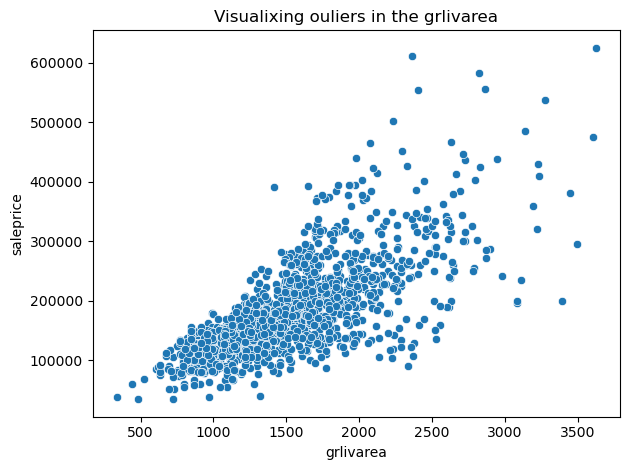

In [13]:
sns.scatterplot(data=df, x="grlivarea", y="saleprice")
plt.title("Visualixing ouliers in the grlivarea")
plt.xlabel("grlivarea")
plt.ylabel("saleprice")
plt.tight_layout()
plt.show()

According to the plot above, the outliers have been removed thus displaying a balanced visual of  saleprice ranging from <100000 to >500000 and the the size of the groung living area between <500 to above 3500

In [14]:
# IQR mothod on the target column
Q1 = df["saleprice"].quantile(0.25)
Q3 = df["saleprice"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR 
upper_bound = Q3 + 1.5 * IQR

cleaned_df = df[(df["saleprice"] >=lower_bound) & (df["saleprice"] <= upper_bound)]

print (f"Real row: {len(df)} \nRow after IQR implied: {len(cleaned_df)}\nDifference between the real and IQR implied rows: {(len(df) - len(cleaned_df))}")

Real row: 1456 
Row after IQR implied: 1397
Difference between the real and IQR implied rows: 59


According to the report shown above, some anomalies building were sold at either extreem lower price though they were big in size while some were exabirantly expensive and this IQR method dealt with them to avoid bias prediction from the future linear regression model that would be built.  
And this decision aid improvement in the model accuracy by ensuring the regression line is not pulled by extreme, non-representative values

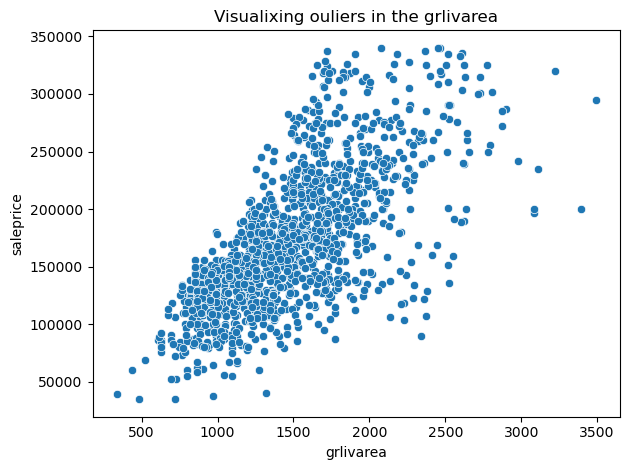

In [15]:
sns.scatterplot(data=cleaned_df, x="grlivarea", y="saleprice")
plt.title("Visualixing ouliers in the grlivarea")
plt.xlabel("grlivarea")
plt.ylabel("saleprice")
plt.tight_layout()
plt.show()

According to the visual above, there is linear relationship between the target and the ground living area  
Now, would like to keep the real df while modelling the cleaned_df without assigning the two together for future use

Analysing the effects of total basement square feet on the target (saleprice).

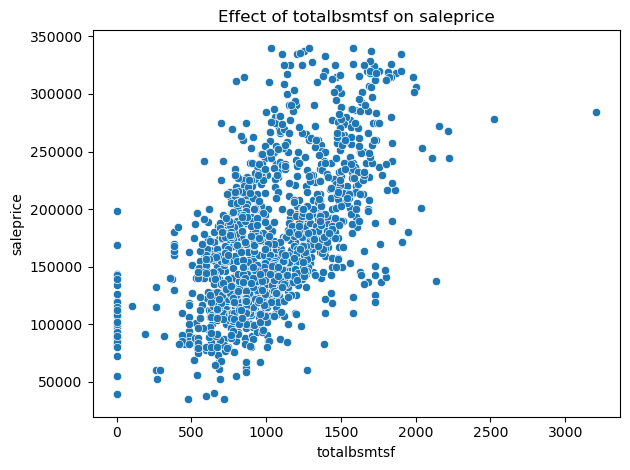

In [16]:
sns.scatterplot(data=cleaned_df, x="totalbsmtsf", y="saleprice")
plt.title("Effect of totalbsmtsf on saleprice")
plt.xlabel("totalbsmtsf")
plt.ylabel("saleprice")
plt.tight_layout()
plt.show()

Base on the scatter plot above, there is a positive correlationa and a linear relationship between total basement square feet and the target column  

To justify the prediction or assumption, kernel density estimation (KDE) plot would identify the direction of the points/boxes if linear or non-lenear

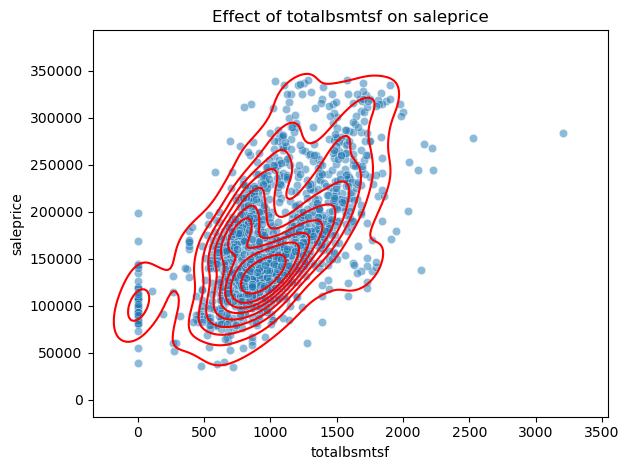

In [17]:
sns.scatterplot(data=cleaned_df, x="totalbsmtsf", y="saleprice", alpha=0.5)
sns.kdeplot(data=cleaned_df, x="totalbsmtsf", y="saleprice", color="red")
plt.title("Effect of totalbsmtsf on saleprice")
plt.xlabel("totalbsmtsf")
plt.ylabel("saleprice")
plt.tight_layout()
plt.show()

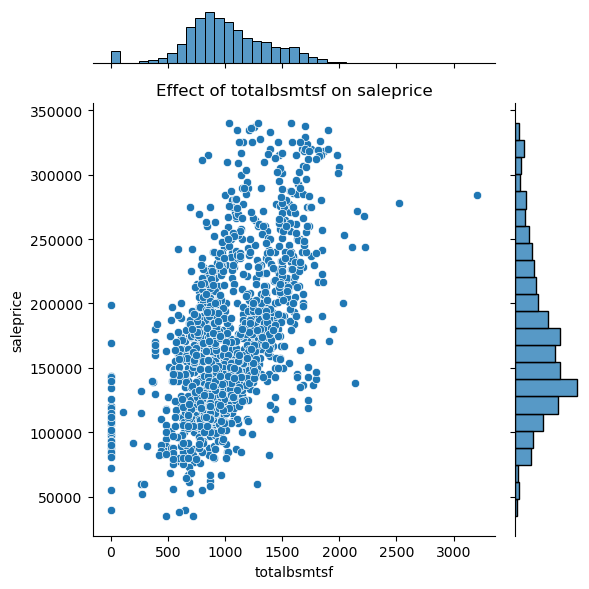

In [18]:
sns.jointplot(data=cleaned_df, x="totalbsmtsf", y="saleprice", kind="scatter", marginal_kws=dict(fill=True))
plt.title("Effect of totalbsmtsf on saleprice")
plt.xlabel("totalbsmtsf")
plt.ylabel("saleprice")
plt.tight_layout()
plt.show()

According to the scatter plot visual above, it shows, as total basement square feet increases, the target column also increase mean means, the more the quarefeet of the basement area, the more the price of the building

Visualizing the effect of overall quality on the price through scatter plot

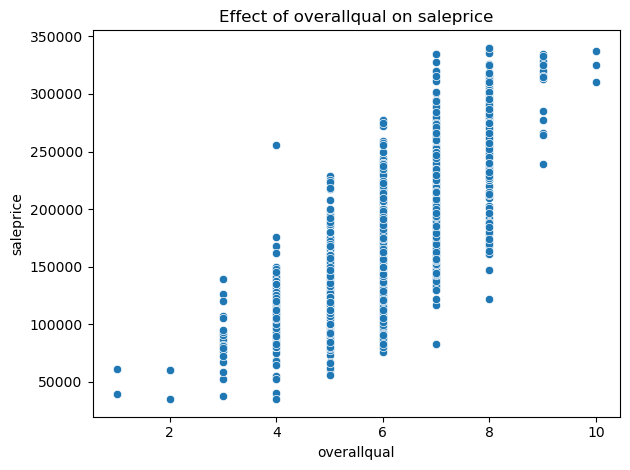

In [19]:
sns.scatterplot(data=cleaned_df, x="overallqual", y="saleprice")
plt.title("Effect of overallqual on saleprice")
plt.xlabel("overallqual")
plt.ylabel("saleprice")
plt.tight_layout()
plt.show()

This above also shows linear relationship between the overall quality and the saleprice which also mean, as the quality increases, so also the price increases.  
For more justification of the linearity relationship between the target and the overall quality, a kernel density estimation (KDE) plot would be executed 

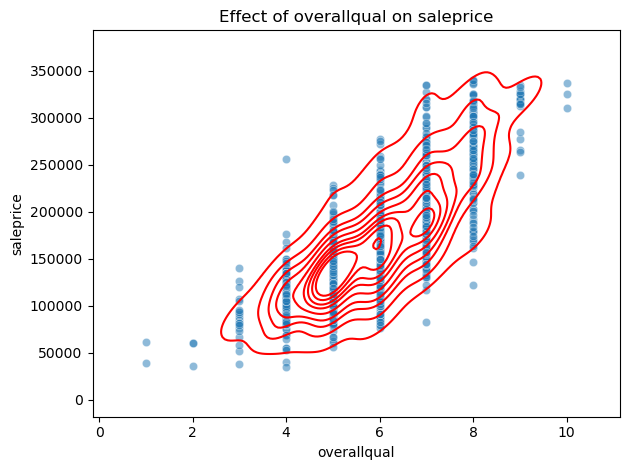

In [20]:
sns.scatterplot(data=cleaned_df, x="overallqual", y="saleprice", alpha=0.5)
sns.kdeplot(data=cleaned_df, x="overallqual", y="saleprice", color="red")
plt.title("Effect of overallqual on saleprice")
plt.xlabel("overallqual")
plt.ylabel("saleprice")
plt.tight_layout()
plt.show()

### VIsualizing the relationship of some categorical columns with the target column

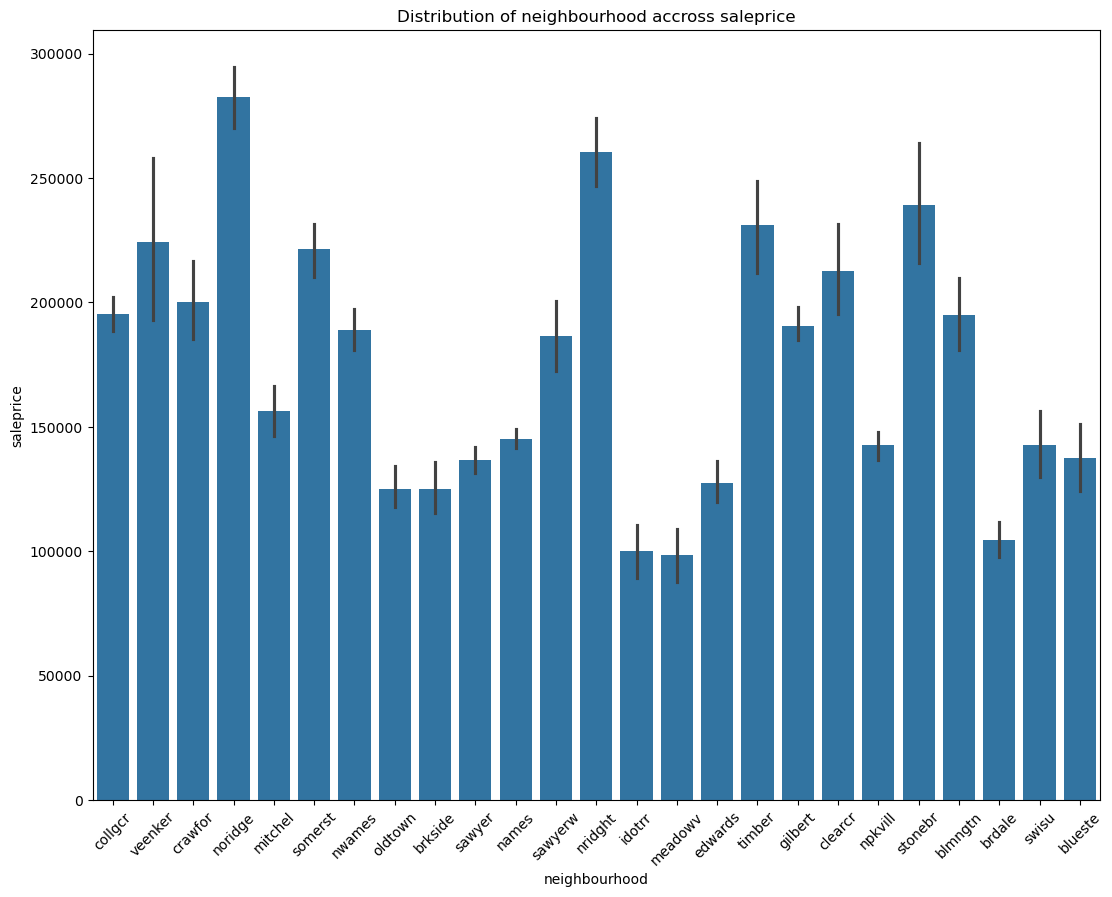

In [21]:
plt.figure(figsize=(13, 10))
sns.barplot(x="neighborhood", y="saleprice", data=cleaned_df)
plt.title("Distribution of neighbourhood accross saleprice")
plt.xlabel("neighbourhood")
plt.ylabel("saleprice")
plt.xticks(rotation=45)
plt.show()

According to the barplot above, it shows the region or neighborhood with higher price and those with lower price and those with lower price are not much compare to those with higher price and this shows that majority of the neighborhood almost fall into the mide range property pricing region

Visualizing the relationship between the target and some categorical fetures which could be one of those catalyst behing price prediction and increment

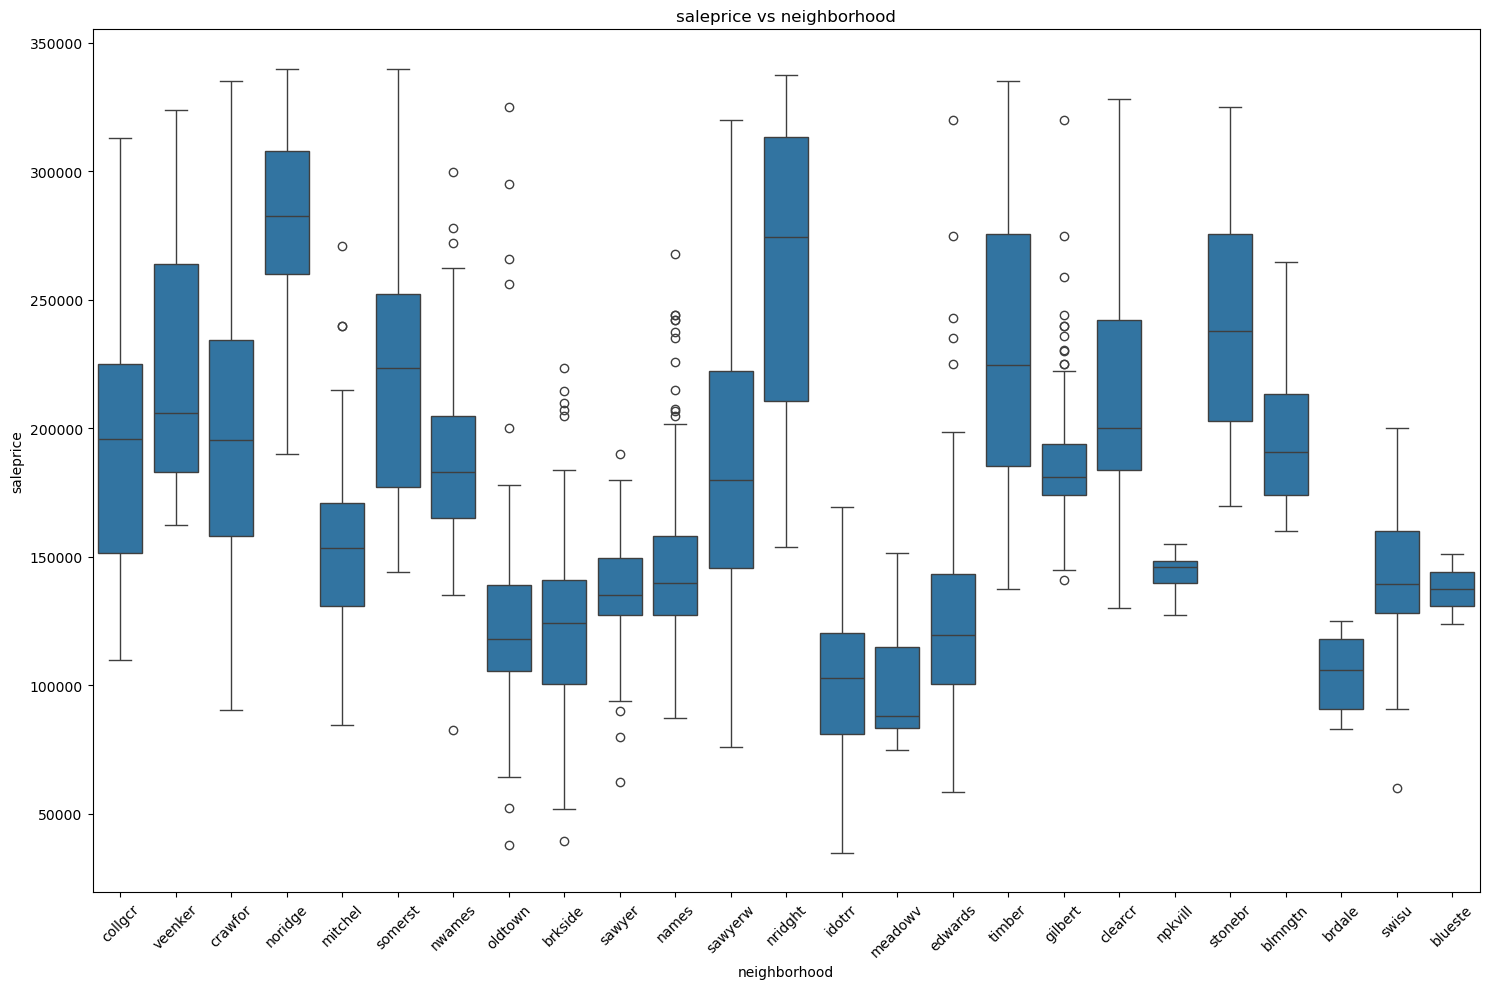

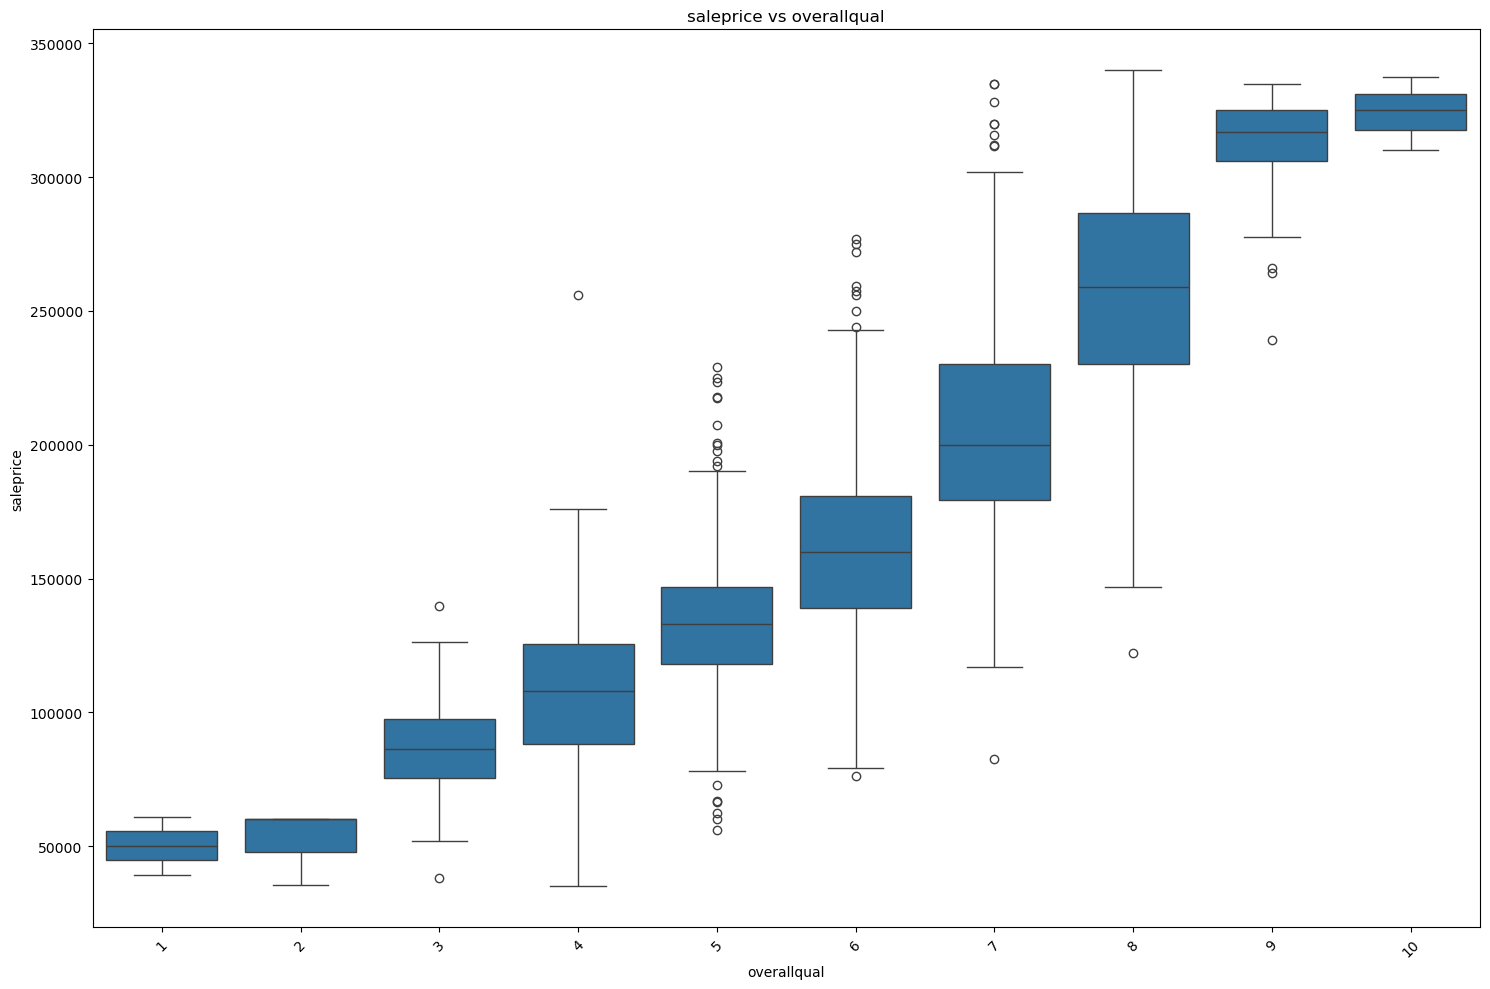

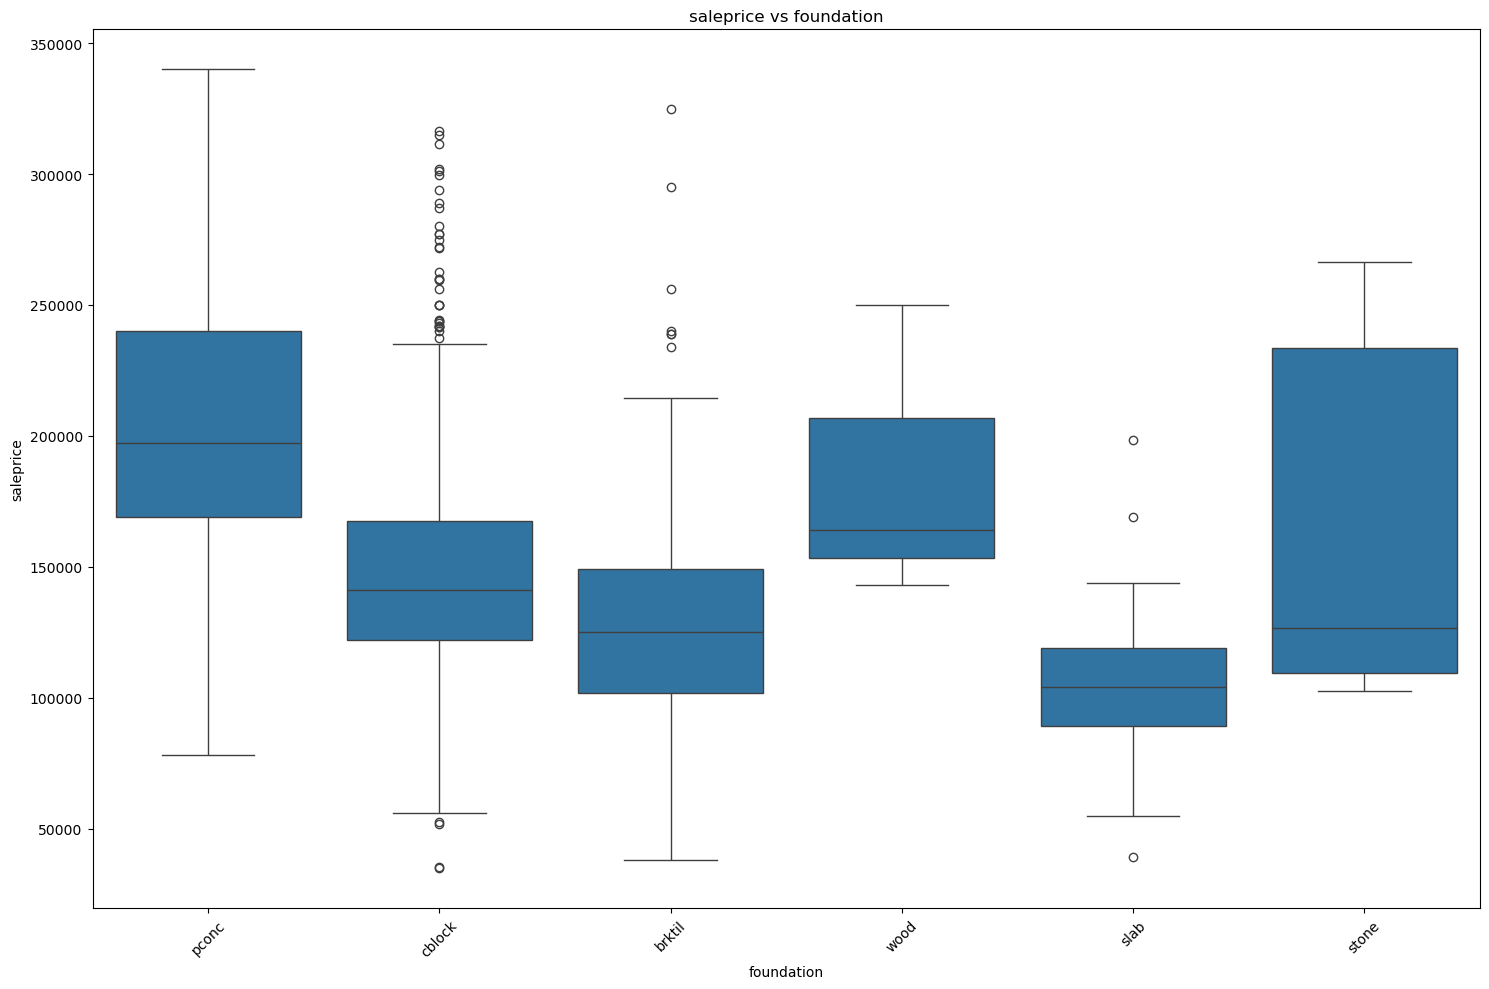

In [22]:
cols = ["neighborhood", "overallqual", "foundation"]

for col in cols: 
    plt.figure(figsize=(15,10))
    sns.boxplot(x=col, y="saleprice", data=cleaned_df)
    plt.title(f"saleprice vs {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

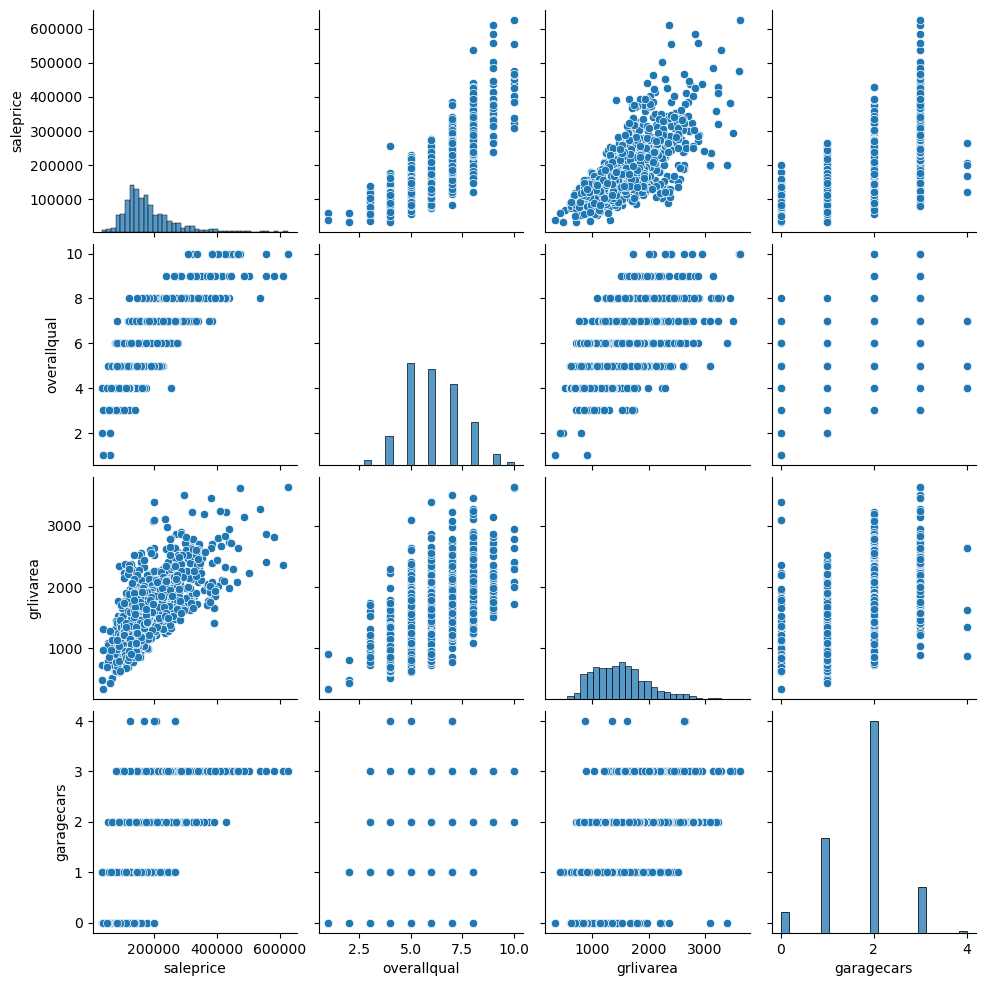

In [23]:
cols = ['saleprice', 'overallqual', 'grlivarea', 'garagecars']
sns.pairplot(df[cols])
plt.show()

According to the above plot/visuals, there is one sured information which is that the pairplots show there is linear relationship between the features plotted against the target

#### Visualizing missing data accross the data theough heatmap

In [24]:
null = (df.isna().mean()*100).sort_values(ascending=False)
null

mssubclass     0.0
garageyrblt    0.0
fireplacequ    0.0
fireplaces     0.0
functional     0.0
              ... 
extercond      0.0
exterqual      0.0
masvnrarea     0.0
exterior2nd    0.0
saleprice      0.0
Length: 74, dtype: float64

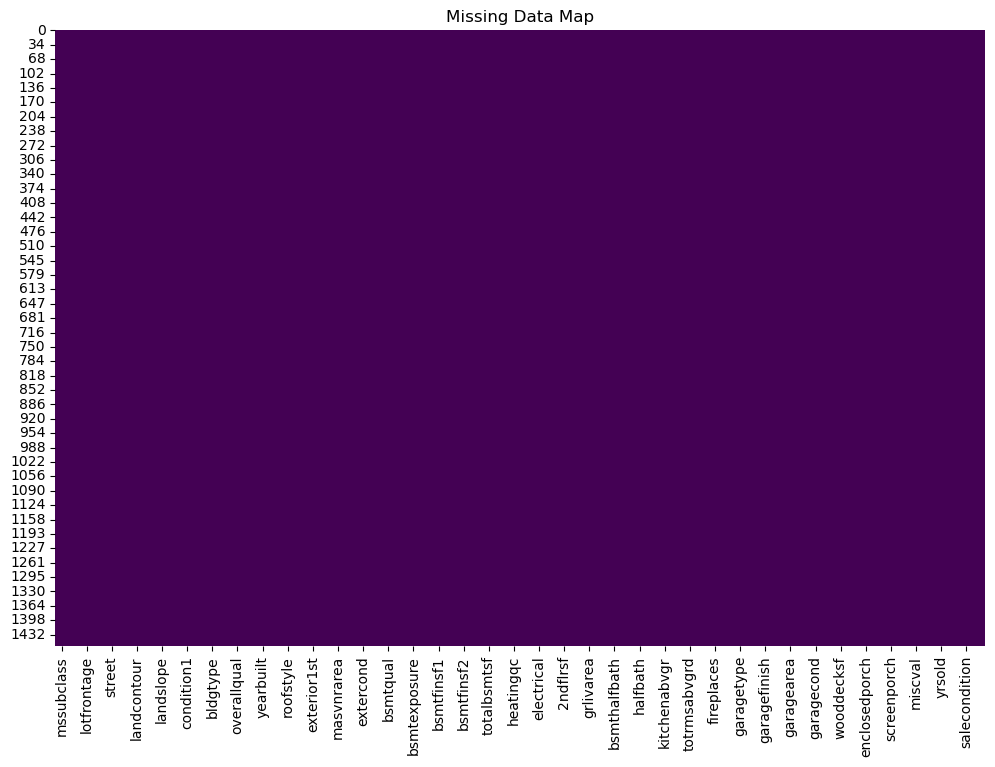

In [25]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Map')
plt.show()

this shows that there is no more null since the plot standby on 0

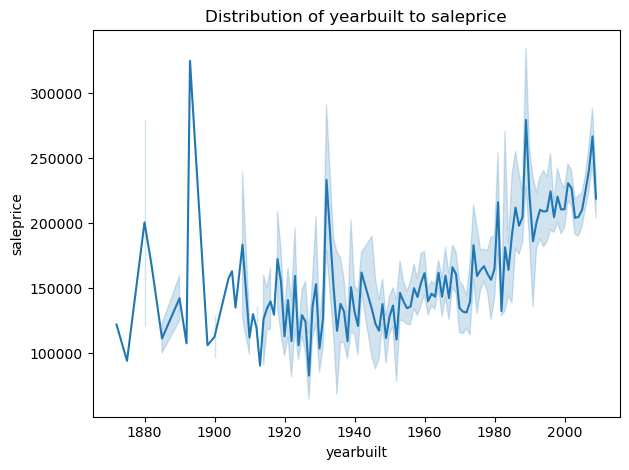

In [26]:
sns.lineplot(x="yearbuilt", y="saleprice", data=cleaned_df)
plt.title("Distribution of yearbuilt to saleprice")
plt.xlabel("yearbuilt")
plt.ylabel("saleprice")
plt.tight_layout()
plt.show()

This shows that majority of the properties are likely old and some might have been renovated. But the line chat signifies a pattern of growth and increment in building the the houses as the year pile upward

Visualizong the heatmap 

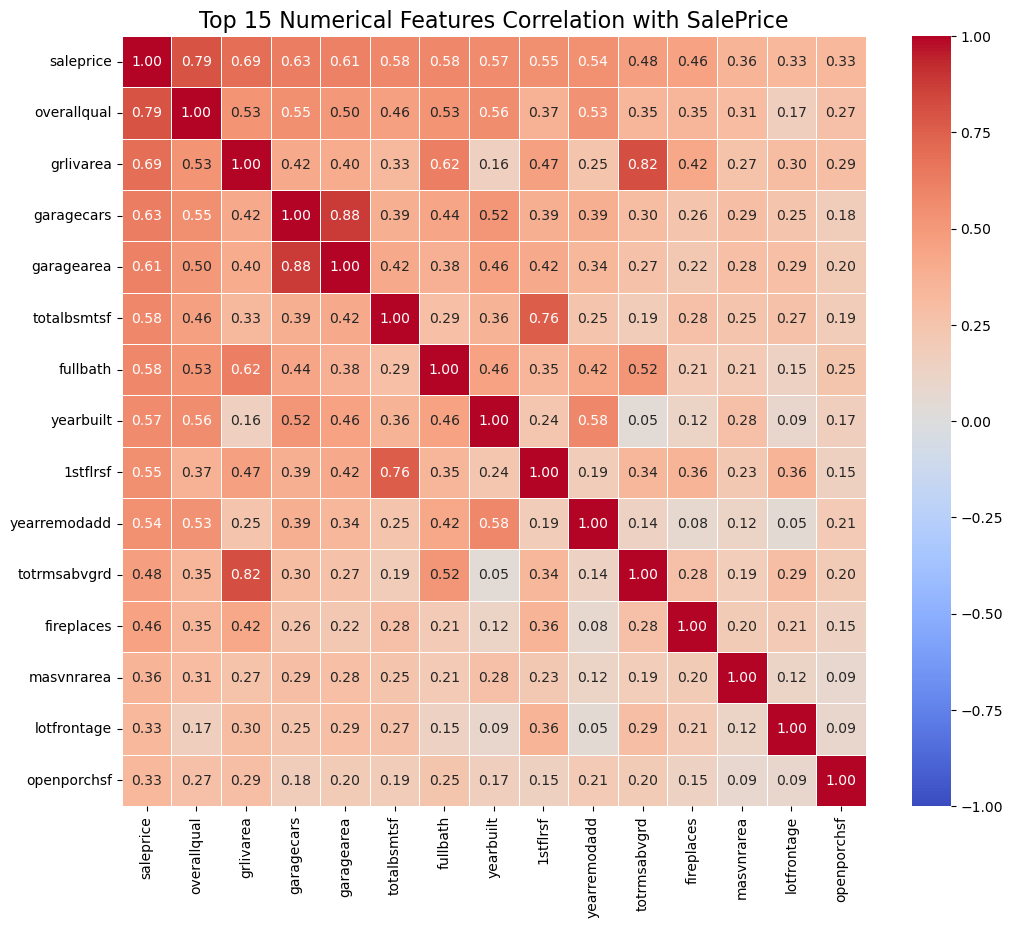

In [27]:
correlations = cleaned_df.corr(numeric_only=True)['saleprice'].sort_values(ascending=False)

top_features = correlations.index[:15]
top_corr_matrix = cleaned_df[top_features].corr()

# 4. Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(top_corr_matrix, 
            annot=True,          # Show the correlation coefficients in the cells
            cmap='coolwarm',     # Red for positive, blue for negative correlation
            fmt=".2f",           # Format values to 2 decimal places
            linewidths=0.5,      # Add small gaps between cells for readability
            vmin=-1, vmax=1)     # Set range for consistent color scaling

plt.title('Top 15 Numerical Features Correlation with SalePrice', fontsize=16)
plt.show()

According to the plot above, the top three price influencers/ high correlated features are overallqual, grlivarea, garacars  
While the least three weak correlated features are openporchsf, lotfrontage, masvnrarea

reassigning the cleaned_df dataframe to the initial df before saving the file as csv

In [28]:
df = cleaned_df

#### Saving the processed file as csv file

In [29]:
df.to_csv("./data/house_processed_data.csv", index=False)

Saving it through the sweetviz allows visualizing the whole features' information through the web browser and it does well to summarize the whole work executed in this EDA stage

In [33]:
import sweetviz as sv
report = sv.analyze(df)
# Saving in order to open in the browser
report.show_html('eda_report.html')

                                             |                                             | [  0%]   00:00 ->…

Report eda_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
